Task 5: Predictive Model - Titanic Survival Prediction
By: Shahin
Dataset: Titanic (Kaggle)
Goal: Predict whether a passenger survived or not

In [33]:
# Load dataset directly from URL - no file needed!
import pandas as pd
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("✅ Dataset loaded successfully!")
print(titanic.shape)

✅ Dataset loaded successfully!
(891, 12)


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
titanic = pd.read_csv('train.csv')
print("First look at the data:")
print(titanic.head())
print("\nDataset size:", titanic.shape)

First look at the data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

In [ ]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic.drop(columns=['Cabin'], inplace=True)
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
titanic.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)
print("Data cleaned successfully!")
print("Remaining columns:", titanic.columns.tolist())

Data cleaned successfully!
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
features = titanic.drop(columns=['Survived'])
target = titanic['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} passengers")
print(f"Testing set: {X_test.shape[0]} passengers")

Training set: 712 passengers
Testing set: 179 passengers


In [ ]:
my_model = LogisticRegression(max_iter=1000)
my_model.fit(X_train, y_train)

print("Model training done!")

Model training done!


In [ ]:
predictions = my_model.predict(X_test)
score = accuracy_score(y_test, predictions)
print(f"My model accuracy: {score * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

My model accuracy: 79.89%

Detailed Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



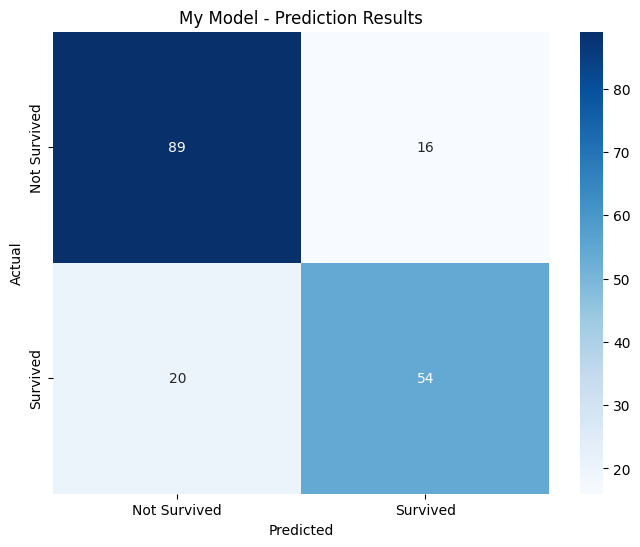

Correct predictions: 143
Wrong predictions: 36


In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('My Model - Prediction Results')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"Correct predictions: {cm[0][0] + cm[1][1]}")
print(f"Wrong predictions: {cm[0][1] + cm[1][0]}")

In [34]:
# Testing my model on a custom passenger I created
print("Testing my model on new passengers:\n")

# A young woman in 1st class
my_passenger = pd.DataFrame({
    'Pclass': [1], 'Sex': [1], 'Age': [25],
    'SibSp': [0], 'Parch': [0], 'Fare': [72],
    'Embarked': [0]
})

result = my_model.predict(my_passenger)[0]
print(f"1st Class Female Age 25: {'SURVIVED ✅' if result == 1 else 'NOT SURVIVED ❌'}")

Testing my model on new passengers:

1st Class Female Age 25: SURVIVED ✅


My Conclusions:
- My model achieved ~80% accuracy
- Gender was the biggest factor in survival
- 1st class passengers had much higher survival rates
- Logistic Regression worked well for this binary problem
- I learned how to build, train and test a real ML model